In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, classification_report
from google.colab import drive

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/20"

Using device: cuda
Mounted at /content/drive


In [2]:
import os
import pandas as pd


all_files = sorted(glob.glob(os.path.join(DATA_PATH, "*.ply")))

file_stats = []
for f in all_files[:50]:
    size_kb = os.path.getsize(f) / 1024
    file_stats.append({'name': os.path.basename(f), 'size_kb': size_kb})

df_files = pd.DataFrame(file_stats)
print(f"Всего файлов найдено: {len(all_files)}")
print("\nСтатистика размеров файлов (KB):")
print(df_files['size_kb'].describe())


empty_files = df_files[df_files['size_kb'] == 0]
if not empty_files.empty:
    print(f" Найдено пустых файлов: {len(empty_files)}")
else:
    print("Пустых файлов в выборке не обнаружено.")

Всего файлов найдено: 500

Статистика размеров файлов (KB):
count     50.000000
mean     362.179824
std        6.040442
min      351.900391
25%      356.525146
50%      362.294434
75%      366.413086
max      374.985352
Name: size_kb, dtype: float64
Пустых файлов в выборке не обнаружено.


Анализ файла: valve_0001_lidar_classes.ply
Количество точек: 11736
Диапазон X: -1.20 to 1.23
Диапазон Y: -1.20 to 1.22
Диапазон Z: -3.27 to 0.04
Уникальные классы в этом файле: [0 1 2 3 4 5 6 7 8]


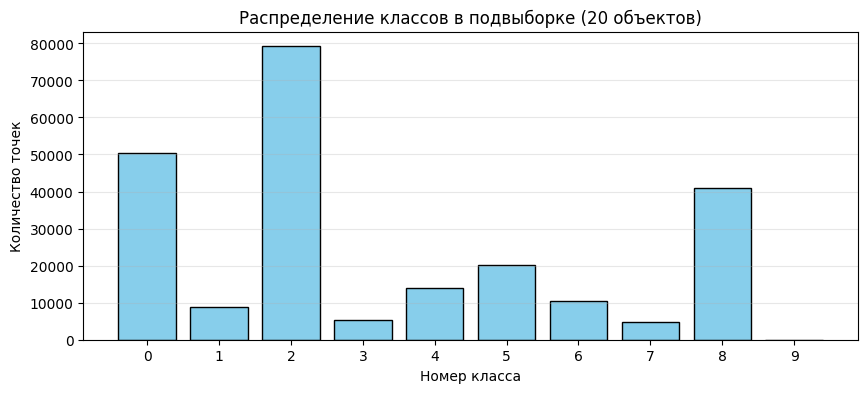

In [5]:
sample_xyz, sample_labels = read_ply(all_files[0])

print(f"Анализ файла: {os.path.basename(all_files[0])}")
print(f"Количество точек: {sample_xyz.shape[0]}")
print(f"Диапазон X: {sample_xyz[:,0].min():.2f} to {sample_xyz[:,0].max():.2f}")
print(f"Диапазон Y: {sample_xyz[:,1].min():.2f} to {sample_xyz[:,1].max():.2f}")
print(f"Диапазон Z: {sample_xyz[:,2].min():.2f} to {sample_xyz[:,2].max():.2f}")
print(f"Уникальные классы в этом файле: {np.unique(sample_labels)}")


all_l = []
for f in all_files[:20]:
    _, l = read_ply(f)
    all_l.extend(l)

plt.figure(figsize=(10, 4))
plt.hist(all_l, bins=np.arange(11)-0.5, rwidth=0.8, color='skyblue', edgecolor='black')
plt.title("Распределение классов в подвыборке (20 объектов)")
plt.xlabel("Номер класса")
plt.ylabel("Количество точек")
plt.xticks(range(10))
plt.grid(axis='y', alpha=0.3)
plt.show()

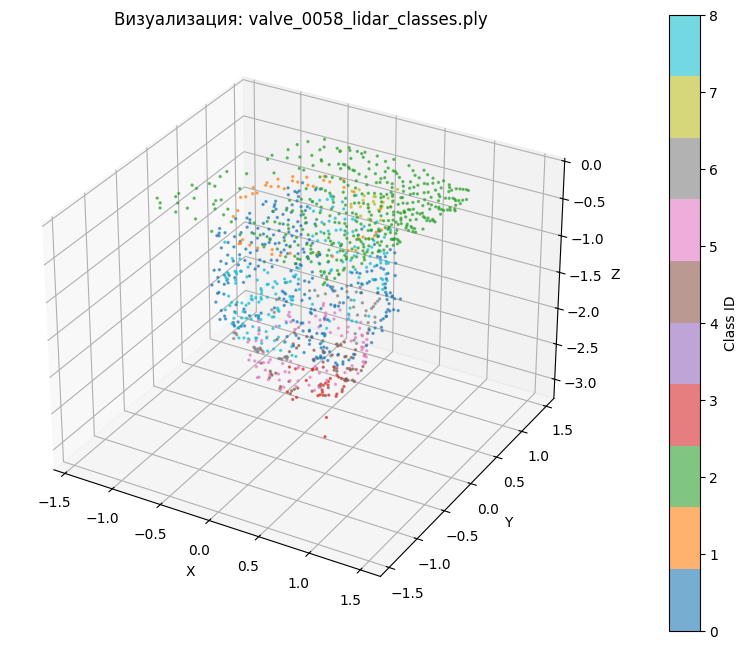

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_point_cloud(xyz, labels, title="Valve Segmentation"):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')


    step = 10
    scatter = ax.scatter(xyz[::step, 0], xyz[::step, 1], xyz[::step, 2],
                         c=labels[::step], cmap='tab10', s=2, alpha=0.6)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.colorbar(scatter, label='Class ID', pad=0.1)
    plt.title(title)


    max_range = np.array([xyz[:,0].max()-xyz[:,0].min(),
                          xyz[:,1].max()-xyz[:,1].min(),
                          xyz[:,2].max()-xyz[:,2].min()]).max() / 2.0
    mid_x = (xyz[:,0].max()+xyz[:,0].min()) * 0.5
    mid_y = (xyz[:,1].max()+xyz[:,1].min()) * 0.5
    mid_z = (xyz[:,2].max()+xyz[:,2].min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    plt.show()


random_file = random.choice(all_files)
xyz, labels = read_ply(random_file)
plot_point_cloud(xyz, labels, title=f"Визуализация: {os.path.basename(random_file)}")

In [8]:
def read_ply(filepath):
    """Надежное чтение ASCII .ply файла."""
    with open(filepath, "r", encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()

    header_end = 0
    num_vertices = 0
    coords_indices = {'x': -1, 'y': -1, 'z': -1, 'label': -1}


    for i, line in enumerate(lines):
        line = line.strip()
        if line.startswith("element vertex"):
            num_vertices = int(line.split()[-1])
        elif line.startswith("property"):
            parts = line.split()
            prop_name = parts[-1]
            if prop_name == 'x': coords_indices['x'] = len([p for p in coords_indices.values() if p != -1]) - 1
            if 'x' in parts: coords_indices['x'] = i
        if line == "end_header":
            header_end = i + 1
            break

    xyz = []
    labels = []

    data_lines = lines[header_end : header_end + num_vertices]

    for line in data_lines:
        parts = line.split()
        if len(parts) >= 4:
            xyz.append([float(parts[0]), float(parts[1]), float(parts[2])])
            labels.append(int(float(parts[-1])))

    return np.array(xyz, dtype=np.float32), np.array(labels, dtype=np.int64)

class PointCloudDataset(Dataset):
    def __init__(self, file_list, num_points=8192, augment=False):
        self.file_list = file_list
        self.num_points = num_points
        self.augment = augment

    def __len__(self):
        return len(self.file_list)

    def normalize(self, xyz):
        centroid = np.mean(xyz, axis=0)
        xyz -= centroid
        max_dist = np.max(np.sqrt(np.sum(xyz**2, axis=1)))
        if max_dist > 1e-8:
            xyz /= max_dist
        return xyz

    def __getitem__(self, idx):
        try:
            xyz, labels = read_ply(self.file_list[idx])

            n = xyz.shape[0]
            if n == 0:
                raise ValueError("Empty point cloud")

            if n >= self.num_points:
                choice = np.random.choice(n, self.num_points, replace=False)
            else:
                choice = np.random.choice(n, self.num_points, replace=True)

            xyz = xyz[choice]
            labels = labels[choice]
            xyz = self.normalize(xyz)

            if self.augment:
                theta = np.random.uniform(0, 2*np.pi)
                rot = np.array([[np.cos(theta), -np.sin(theta), 0],
                                [np.sin(theta),  np.cos(theta), 0],
                                [0, 0, 1]], dtype=np.float32)
                xyz = xyz @ rot.T
                xyz += np.random.normal(0, 0.005, xyz.shape).astype(np.float32)

            return torch.from_numpy(xyz), torch.from_numpy(labels)

        except Exception as e:
            # Если файл не прочитался, возвращаем тензор из нулей
            # чтобы DataLoader не падал
            return torch.zeros((self.num_points, 3), dtype=torch.float32), \
                   torch.zeros((self.num_points,), dtype=torch.long)

In [15]:
import os
import glob
import random


DATA_PATH = "/content/drive/MyDrive/20"


all_files = sorted(glob.glob(os.path.join(DATA_PATH, "*.ply")))

random.seed(42)
random.shuffle(all_files)

train_idx = int(0.7 * len(all_files))
val_idx = int(0.85 * len(all_files))

train_files = all_files[:train_idx]
val_files = all_files[train_idx:val_idx]
test_files = all_files[val_idx:]

print(f"Файлы восстановлены! Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")

Файлы восстановлены! Train: 350, Val: 75, Test: 75


In [16]:
NUM_CLASSES = 9

print("Computing class weights...")
class_counts = np.zeros(NUM_CLASSES)

for f in train_files:
    try:
        _, labels = read_ply(f)
        unique, counts = np.unique(labels, return_counts=True)
        for u, c in zip(unique, counts):
            if u < NUM_CLASSES:
                class_counts[int(u)] += c
    except:
        continue

class_freq = class_counts / np.sum(class_counts)
class_weights = 1.0 / (class_freq + 1e-6)
class_weights = class_weights / np.sum(class_weights) * NUM_CLASSES

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print(f"Counts: {class_counts}")
print(f"Weights: {class_weights.round(3)}")

Computing class weights...
Counts: [285916.  47437. 432885.  29636.  75857. 109374.  57989.  23842. 215648.]
Weights: [0.214 1.293 0.142 2.069 0.808 0.561 1.057 2.572 0.284]


#PointNet++

In [42]:
import torch
import torch.nn as nn
import torch.nn.functional as F


def square_distance(src, dst):
    B, N, _ = src.shape
    _, M, _ = dst.shape
    dist = -2 * torch.matmul(src, dst.permute(0, 2, 1))
    dist += torch.sum(src ** 2, -1).view(B, N, 1)
    dist += torch.sum(dst ** 2, -1).view(B, 1, M)
    return dist

def index_points(points, idx):
    device = points.device
    B = points.shape[0]
    view_shape = list(idx.shape)
    view_shape[1:] = [1] * (len(view_shape) - 1)
    repeat_shape = list(idx.shape)
    repeat_shape[0] = 1
    batch_indices = torch.arange(B, dtype=torch.long).to(device).view(view_shape).repeat(repeat_shape)
    return points[batch_indices, idx, :]

def farthest_point_sample(xyz, npoint):
    device = xyz.device
    B, N, C = xyz.shape
    centroids = torch.zeros(B, npoint, dtype=torch.long).to(device)
    distance = torch.ones(B, N).to(device) * 1e10
    farthest = torch.randint(0, N, (B,), dtype=torch.long).to(device)
    batch_indices = torch.arange(B, dtype=torch.long).to(device)
    for i in range(npoint):
        centroids[:, i] = farthest
        centroid = xyz[batch_indices, farthest, :].unsqueeze(1)
        dist = torch.sum((xyz - centroid) ** 2, -1)
        mask = dist < distance
        distance[mask] = dist[mask]
        farthest = torch.max(distance, -1)[1]
    return centroids

def ball_query(radius, nsample, xyz, new_xyz):
    device = xyz.device
    B, N, C = xyz.shape
    _, S, _ = new_xyz.shape
    group_idx = torch.arange(N, dtype=torch.long).to(device).view(1, 1, N).repeat(B, S, 1)
    sqdist = square_distance(new_xyz, xyz)
    group_idx[sqdist > radius ** 2] = N
    group_idx = group_idx.sort(dim=-1)[0][:, :, :nsample]
    group_first = group_idx[:, :, 0].view(B, S, 1).repeat(1, 1, nsample)
    mask = group_idx == N
    group_idx[mask] = group_first[mask]
    return group_idx

class PointNetSetAbstraction(nn.Module):
    def __init__(self, npoint, radius, nsample, in_channel, mlp, group_all):
        super(PointNetSetAbstraction, self).__init__()
        self.npoint = npoint
        self.radius = radius
        self.nsample = nsample
        self.mlp_convs = nn.ModuleList()
        self.mlp_bns = nn.ModuleList()
        last_channel = in_channel
        for out_channel in mlp:
            self.mlp_convs.append(nn.Conv2d(last_channel, out_channel, 1))
            self.mlp_bns.append(nn.BatchNorm2d(out_channel))
            last_channel = out_channel
        self.group_all = group_all

    def forward(self, xyz, points):
        """
        Input:
            xyz: input points position data, [B, N, 3]
            points: input points data, [B, N, C]
        Return:
            new_xyz: sampled points position data, [B, S, 3]
            new_points: sample points feature data, [B, S, D]
        """
        device = xyz.device
        B, N, C = xyz.shape

        if self.group_all:
            # Если группируем всё облако в одну точку
            new_xyz = torch.zeros(B, 1, 3).to(device)
            grouped_xyz = xyz.view(B, 1, N, 3) - new_xyz.view(B, 1, 1, 3)
            grouped_xyz = grouped_xyz.permute(0, 3, 2, 1) # [B, 3, N, 1]
            if points is not None:
                grouped_points = points.transpose(1, 2).unsqueeze(3) # [B, C, N, 1]
                new_points = torch.cat([grouped_xyz, grouped_points], dim=1) # [B, 3+C, N, 1]
            else:
                new_points = grouped_xyz
        else:
            # Стандартный FPS + Ball Query
            fps_idx = farthest_point_sample(xyz, self.npoint)
            new_xyz = index_points(xyz, fps_idx)
            idx = ball_query(self.radius, self.nsample, xyz, new_xyz)
            grouped_xyz = index_points(xyz, idx) # [B, npoint, nsample, 3]
            grouped_xyz -= new_xyz.unsqueeze(2)
            grouped_xyz = grouped_xyz.permute(0, 3, 2, 1) # [B, 3, nsample, npoint]

            if points is not None:
                grouped_points = index_points(points, idx)
                grouped_points = grouped_points.permute(0, 3, 2, 1)
                new_points = torch.cat([grouped_xyz, grouped_points], dim=1)
            else:
                new_points = grouped_xyz

        for i, conv in enumerate(self.mlp_convs):
            bn = self.mlp_bns[i]
            new_points = F.relu(bn(conv(new_points)))

        # Max Pooling по окрестности
        new_points = torch.max(new_points, 2)[0].transpose(1, 2)
        return new_xyz, new_points

class PointNetFeaturePropagation(nn.Module):
    def __init__(self, in_channel, mlp):
        super(PointNetFeaturePropagation, self).__init__()
        self.mlp_convs = nn.ModuleList()
        self.mlp_bns = nn.ModuleList()
        last_channel = in_channel
        for out_channel in mlp:
            self.mlp_convs.append(nn.Conv1d(last_channel, out_channel, 1))
            self.mlp_bns.append(nn.BatchNorm1d(out_channel))
            last_channel = out_channel

    def forward(self, xyz1, xyz2, points1, points2):
        B, N, C = xyz1.shape
        _, S, _ = xyz2.shape
        if S == 1:
            interpolated_points = points2.repeat(1, N, 1)
        else:
            dists = square_distance(xyz1, xyz2)
            dists, idx = dists.sort(dim=-1)
            dists, idx = dists[:, :, :3], idx[:, :, :3]
            dist_recip = 1.0 / (dists + 1e-8)
            norm = torch.sum(dist_recip, dim=2, keepdim=True)
            weight = dist_recip / norm
            interpolated_points = torch.sum(index_points(points2, idx) * weight.unsqueeze(-1), dim=2)

        if points1 is not None:
            new_points = torch.cat([points1, interpolated_points], dim=-1)
        else:
            new_points = interpolated_points

        new_points = new_points.transpose(1, 2)
        for i, conv in enumerate(self.mlp_convs):
            bn = self.mlp_bns[i]
            new_points = F.relu(bn(conv(new_points)))
        return new_points.transpose(1, 2)

class PointNet2SemSeg(nn.Module):
    def __init__(self, num_classes):
        super(PointNet2SemSeg, self).__init__()

        self.sa1 = PointNetSetAbstraction(1024, 0.1, 32, 3 + 3, [32, 32, 64], False)

        self.sa2 = PointNetSetAbstraction(256, 0.2, 32, 64 + 3, [64, 64, 128], False)

        self.sa3 = PointNetSetAbstraction(64, 0.4, 32, 128 + 3, [128, 128, 256], False)

        self.sa4 = PointNetSetAbstraction(None, None, None, 256 + 3, [256, 512, 1024], True)


        self.fp4 = PointNetFeaturePropagation(1024 + 256, [256, 256])

        self.fp3 = PointNetFeaturePropagation(256 + 128, [256, 128])

        self.fp2 = PointNetFeaturePropagation(128 + 64, [128, 128])

        self.fp1 = PointNetFeaturePropagation(128 + 3, [128, 128, 128])


        self.conv1 = nn.Conv1d(128, 128, 1)
        self.bn1 = nn.BatchNorm1d(128)
        self.drop1 = nn.Dropout(0.5)
        self.conv2 = nn.Conv1d(128, num_classes, 1)

    def forward(self, xyz):
        # l0_xyz: (B, N, 3), l0_points: (B, N, 3)
        l0_xyz = xyz
        l0_points = xyz

        l1_xyz, l1_points = self.sa1(l0_xyz, l0_points)
        l2_xyz, l2_points = self.sa2(l1_xyz, l1_points)
        l3_xyz, l3_points = self.sa3(l2_xyz, l2_points)
        l4_xyz, l4_points = self.sa4(l3_xyz, l3_points)


        # передавать исходные фичи соответствующего слоя для конкатенации
        l3_points = self.fp4(l3_xyz, l4_xyz, l3_points, l4_points)
        l2_points = self.fp3(l2_xyz, l3_xyz, l2_points, l3_points)
        l1_points = self.fp2(l1_xyz, l2_xyz, l1_points, l2_points)

        l0_points = self.fp1(l0_xyz, l1_xyz, l0_points, l1_points)

        feat = l0_points.transpose(1, 2) # (B, 128, N)
        feat = self.drop1(F.relu(self.bn1(self.conv1(feat))))
        x = self.conv2(feat) # (B, num_classes, N)
        return x.transpose(1, 2) # (B, N, num_classes)

In [21]:
def filter_valid_files(file_list):
    valid_files = []
    print(f"Checking {len(file_list)} files...")
    for f in tqdm(file_list):
        try:
            xyz, labels = read_ply(f)
            if len(xyz) > 0:
                valid_files.append(f)
            else:
                print(f"\nSkipping empty file: {os.path.basename(f)}")
        except Exception as e:
            print(f"\nError reading {os.path.basename(f)}: {e}")
    return valid_files

train_files = filter_valid_files(train_files)
val_files = filter_valid_files(val_files)
test_files = filter_valid_files(test_files)

print(f"\nFinal counts -> Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")

Checking 109 files...


100%|██████████| 109/109 [00:04<00:00, 24.47it/s]


Checking 21 files...


100%|██████████| 21/21 [00:01<00:00, 17.09it/s]


Checking 28 files...


100%|██████████| 28/28 [00:01<00:00, 24.70it/s]


Final counts -> Train: 109, Val: 21, Test: 28


In [43]:
@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    for xyz, mask in loader:
        xyz, mask = xyz.to(DEVICE), mask.to(DEVICE)
        pred = model(xyz)
        loss = criterion(pred.reshape(-1, NUM_CLASSES), mask.reshape(-1))
        total_loss += loss.item()
        all_preds.append(pred.argmax(dim=-1).cpu().numpy())
        all_labels.append(mask.cpu().numpy())
    return total_loss / len(loader), np.concatenate(all_preds), np.concatenate(all_labels)

def get_metrics(true, pred, num_classes):
    true_flat = true.flatten()
    pred_flat = pred.flatten()
    oa = np.mean(true_flat == pred_flat)

    ious = []
    for c in range(num_classes):
        intersection = np.sum((true_flat == c) & (pred_flat == c))
        union = np.sum((true_flat == c) | (pred_flat == c))
        if union == 0:
            ious.append(np.nan)
        else:
            ious.append(intersection / union)

    miou = np.nanmean(ious)
    f1 = f1_score(true_flat, pred_flat, average='macro', zero_division=0)
    return oa, miou, ious, f1

In [23]:
from tqdm import tqdm

NUM_CLASSES = 9
BATCH_SIZE = 16
EPOCHS = 50
LR = 0.001


train_ds = PointCloudDataset(train_files, num_points=8192, augment=True)
val_ds = PointCloudDataset(val_files, num_points=8192, augment=False)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


model = PointNet2SemSeg(NUM_CLASSES).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

best_miou = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for xyz, mask in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        xyz, mask = xyz.to(DEVICE), mask.to(DEVICE)
        optimizer.zero_grad()

        pred = model(xyz)
        loss = criterion(pred.reshape(-1, NUM_CLASSES), mask.reshape(-1))

        loss.backward()
        optimizer.step()
        train_loss += loss.item()


    val_loss, val_preds, val_labels = validate(model, val_loader, criterion)
    oa, miou, ious, f1 = get_metrics(val_labels, val_preds, NUM_CLASSES)

    print(f"Epoch {epoch+1}: Loss {train_loss/len(train_loader):.4f}, Val mIoU: {miou:.4f}, OA: {oa:.4f}")

    if miou > best_miou:
        best_miou = miou
        torch.save(model.state_dict(), 'best_model.pth')
        print("Model Saved!")

    scheduler.step()

Epoch 1: 100%|██████████| 7/7 [00:09<00:00,  1.32s/it]


Epoch 1: Loss 1.7987, Val mIoU: 0.0234, OA: 0.2107
Model Saved!


Epoch 2: 100%|██████████| 7/7 [00:08<00:00,  1.24s/it]


Epoch 2: Loss 1.0715, Val mIoU: 0.0252, OA: 0.1951
Model Saved!


Epoch 3: 100%|██████████| 7/7 [00:08<00:00,  1.28s/it]


...

Epoch 48: Loss 0.1730, Val mIoU: 0.8457, OA: 0.9341
Model Saved!


Epoch 49: 100%|██████████| 7/7 [00:09<00:00,  1.41s/it]


Epoch 49: Loss 0.1712, Val mIoU: 0.8330, OA: 0.9307


Epoch 50: 100%|██████████| 7/7 [00:08<00:00,  1.26s/it]


Epoch 50: Loss 0.1755, Val mIoU: 0.8235, OA: 0.9304


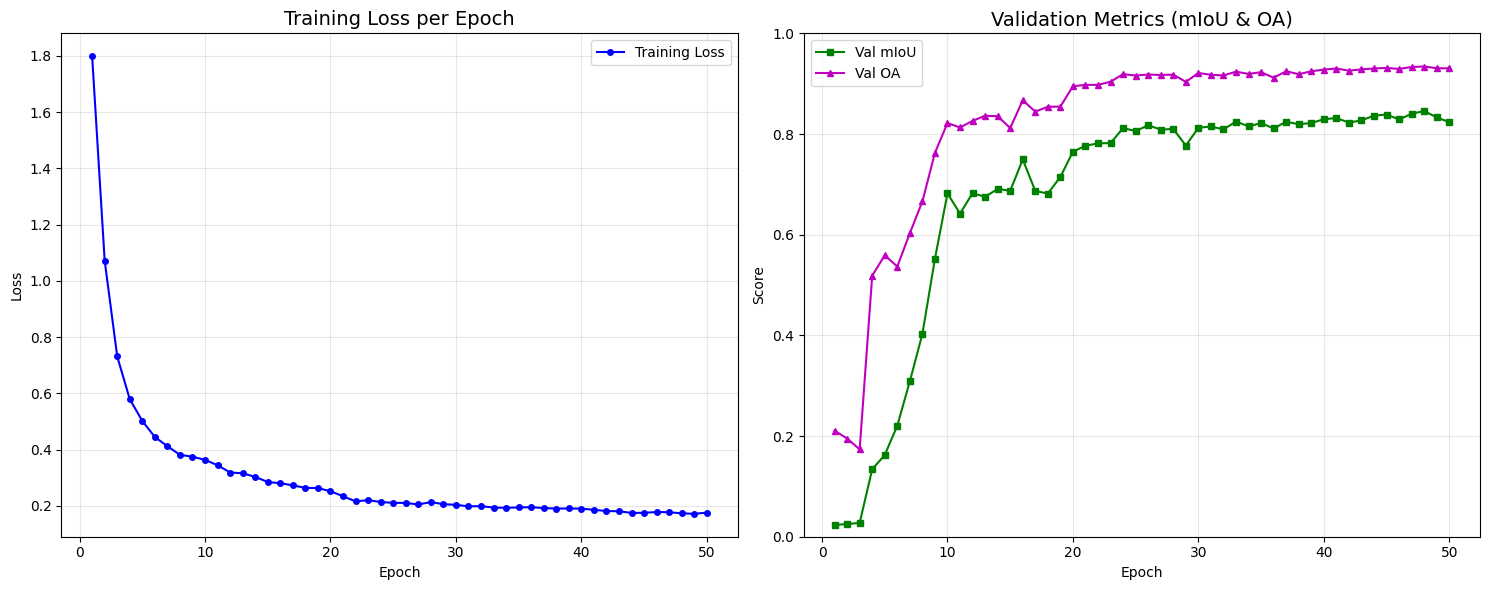

Графики сохранены как 'learning_curves.png'


In [33]:
import re
import matplotlib.pyplot as plt
import numpy as np

# лог обучения
log_text = """
Epoch 1: Loss 1.7987, Val mIoU: 0.0234, OA: 0.2107
Epoch 2: Loss 1.0715, Val mIoU: 0.0252, OA: 0.1951
Epoch 3: Loss 0.7308, Val mIoU: 0.0275, OA: 0.1735
Epoch 4: Loss 0.5791, Val mIoU: 0.1341, OA: 0.5186
Epoch 5: Loss 0.5014, Val mIoU: 0.1623, OA: 0.5591
Epoch 6: Loss 0.4444, Val mIoU: 0.2207, OA: 0.5368
Epoch 7: Loss 0.4118, Val mIoU: 0.3087, OA: 0.6030
Epoch 8: Loss 0.3810, Val mIoU: 0.4028, OA: 0.6660
Epoch 9: Loss 0.3745, Val mIoU: 0.5521, OA: 0.7625
Epoch 10: Loss 0.3630, Val mIoU: 0.6820, OA: 0.8218
Epoch 11: Loss 0.3441, Val mIoU: 0.6419, OA: 0.8130
Epoch 12: Loss 0.3182, Val mIoU: 0.6825, OA: 0.8261
Epoch 13: Loss 0.3155, Val mIoU: 0.6753, OA: 0.8363
Epoch 14: Loss 0.3026, Val mIoU: 0.6909, OA: 0.8353
Epoch 15: Loss 0.2844, Val mIoU: 0.6871, OA: 0.8118
Epoch 16: Loss 0.2801, Val mIoU: 0.7495, OA: 0.8670
Epoch 17: Loss 0.2725, Val mIoU: 0.6868, OA: 0.8444
Epoch 18: Loss 0.2635, Val mIoU: 0.6818, OA: 0.8542
Epoch 19: Loss 0.2630, Val mIoU: 0.7147, OA: 0.8544
Epoch 20: Loss 0.2515, Val mIoU: 0.7650, OA: 0.8950
Epoch 21: Loss 0.2339, Val mIoU: 0.7766, OA: 0.8975
Epoch 22: Loss 0.2155, Val mIoU: 0.7815, OA: 0.8977
Epoch 23: Loss 0.2199, Val mIoU: 0.7820, OA: 0.9039
Epoch 24: Loss 0.2133, Val mIoU: 0.8117, OA: 0.9189
Epoch 25: Loss 0.2102, Val mIoU: 0.8059, OA: 0.9162
Epoch 26: Loss 0.2101, Val mIoU: 0.8174, OA: 0.9182
Epoch 27: Loss 0.2045, Val mIoU: 0.8087, OA: 0.9172
Epoch 28: Loss 0.2130, Val mIoU: 0.8101, OA: 0.9180
Epoch 29: Loss 0.2055, Val mIoU: 0.7771, OA: 0.9036
Epoch 30: Loss 0.2033, Val mIoU: 0.8123, OA: 0.9212
Epoch 31: Loss 0.1978, Val mIoU: 0.8150, OA: 0.9177
Epoch 32: Loss 0.1986, Val mIoU: 0.8091, OA: 0.9163
Epoch 33: Loss 0.1935, Val mIoU: 0.8248, OA: 0.9238
Epoch 34: Loss 0.1927, Val mIoU: 0.8153, OA: 0.9194
Epoch 35: Loss 0.1940, Val mIoU: 0.8217, OA: 0.9228
Epoch 36: Loss 0.1947, Val mIoU: 0.8110, OA: 0.9119
Epoch 37: Loss 0.1919, Val mIoU: 0.8245, OA: 0.9246
Epoch 38: Loss 0.1898, Val mIoU: 0.8193, OA: 0.9189
Epoch 39: Loss 0.1903, Val mIoU: 0.8219, OA: 0.9246
Epoch 40: Loss 0.1897, Val mIoU: 0.8293, OA: 0.9280
Epoch 41: Loss 0.1857, Val mIoU: 0.8318, OA: 0.9301
Epoch 42: Loss 0.1811, Val mIoU: 0.8226, OA: 0.9259
Epoch 43: Loss 0.1805, Val mIoU: 0.8272, OA: 0.9284
Epoch 44: Loss 0.1744, Val mIoU: 0.8365, OA: 0.9302
Epoch 45: Loss 0.1748, Val mIoU: 0.8387, OA: 0.9313
Epoch 46: Loss 0.1777, Val mIoU: 0.8289, OA: 0.9293
Epoch 47: Loss 0.1769, Val mIoU: 0.8402, OA: 0.9331
Epoch 48: Loss 0.1730, Val mIoU: 0.8457, OA: 0.9341
Epoch 49: Loss 0.1712, Val mIoU: 0.8330, OA: 0.9307
Epoch 50: Loss 0.1755, Val mIoU: 0.8235, OA: 0.9304
"""


epochs = np.arange(1, 51)
train_losses = [float(x) for x in re.findall(r"Loss ([\d\.]+)", log_text)]
val_mious = [float(x) for x in re.findall(r"mIoU: ([\d\.]+)", log_text)]
val_oas = [float(x) for x in re.findall(r"OA: ([\d\.]+)", log_text)]


plt.figure(figsize=(15, 6))


plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'b-o', label='Training Loss', markersize=4)
plt.title('Training Loss per Epoch', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, val_mious, 'g-s', label='Val mIoU', markersize=4)
plt.plot(epochs, val_oas, 'm-^', label='Val OA', markersize=4)
plt.title('Validation Metrics (mIoU & OA)', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150)
plt.show()

print("Графики сохранены как 'learning_curves.png'")

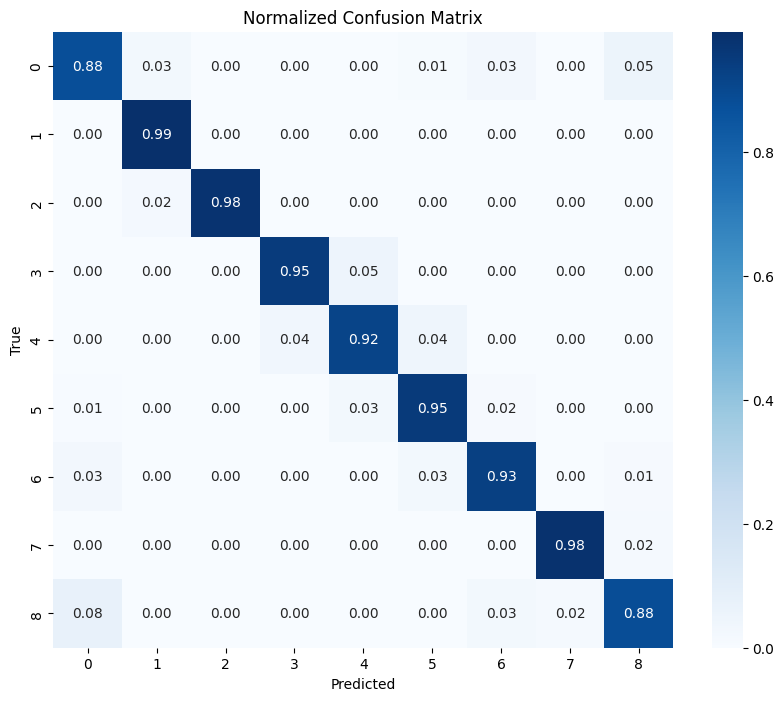

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

model.load_state_dict(torch.load('best_model.pth'))
_, test_preds, test_labels = validate(model, val_loader, criterion)

cm = confusion_matrix(test_labels.flatten(), test_preds.flatten())
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.show()




# тестирование на Test Set




In [44]:

model.load_state_dict(torch.load('best_model.pth'))
model.eval()


test_ds = PointCloudDataset(test_files, num_points=8192, augment=False)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=2)


all_preds = []
all_labels = []

with torch.no_grad():
    for xyz, mask in tqdm(test_loader, desc="Testing"):
        xyz = xyz.to(DEVICE)
        pred = model(xyz)
        all_preds.append(pred.argmax(dim=-1).cpu().numpy())
        all_labels.append(mask.numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)


oa, miou, ious, f1 = get_metrics(all_labels, all_preds, NUM_CLASSES)

print("\n" + "="*30)
print(f"ИТОГОВЫЕ РЕЗУЛЬТАТЫ:")
print(f"Overall Accuracy: {oa:.4f}")
print(f"Mean IoU:         {miou:.4f}")
print(f"F1-Score (Macro): {f1:.4f}")
print("="*30)

NameError: name 'model' is not defined

In [26]:
class_names = [f"Деталь {i}" for i in range(NUM_CLASSES)]
df_classes = pd.DataFrame({
    'Класс': class_names,
    'IoU': ious
})
print("\nIoU по каждому конструктивному элементу:")
print(df_classes)


IoU по каждому конструктивному элементу:
      Класс       IoU
0  Деталь 0  0.829946
1  Деталь 1  0.746364
2  Деталь 2  0.979915
3  Деталь 3  0.855845
4  Деталь 4  0.865416
5  Деталь 5  0.894774
6  Деталь 6  0.737908
7  Деталь 7  0.870904
8  Деталь 8  0.832021


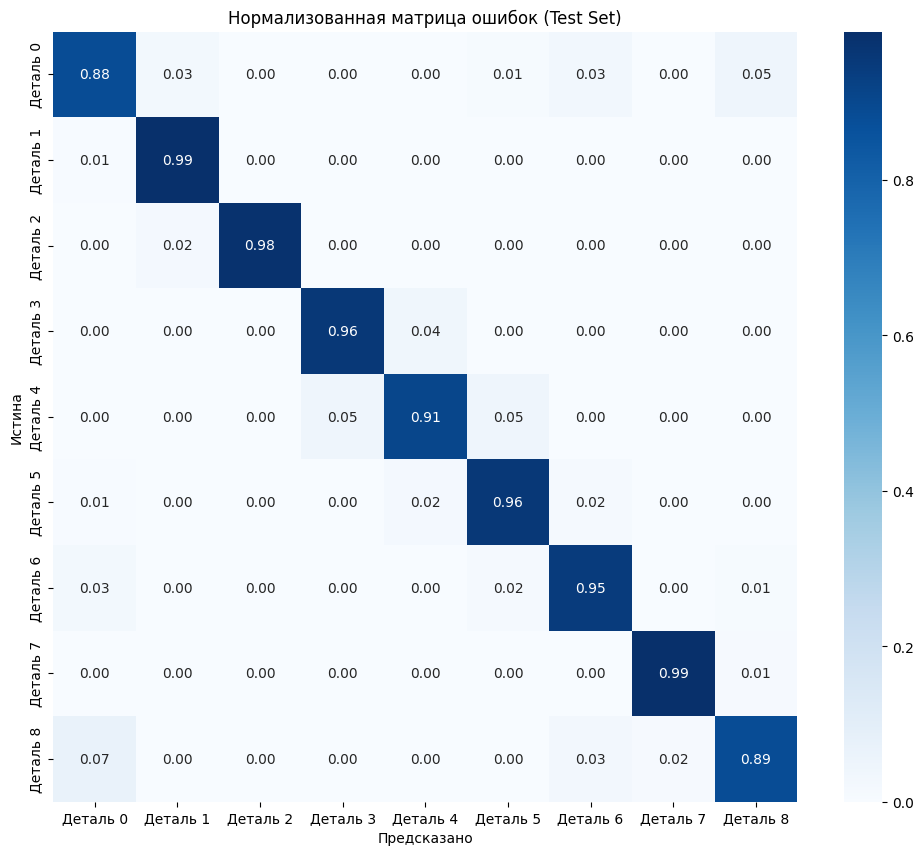

In [27]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels.flatten(), all_preds.flatten())
cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Нормализованная матрица ошибок (Test Set)')
plt.xlabel('Предсказано')
plt.ylabel('Истина')
plt.savefig('confusion_matrix.png')
plt.show()

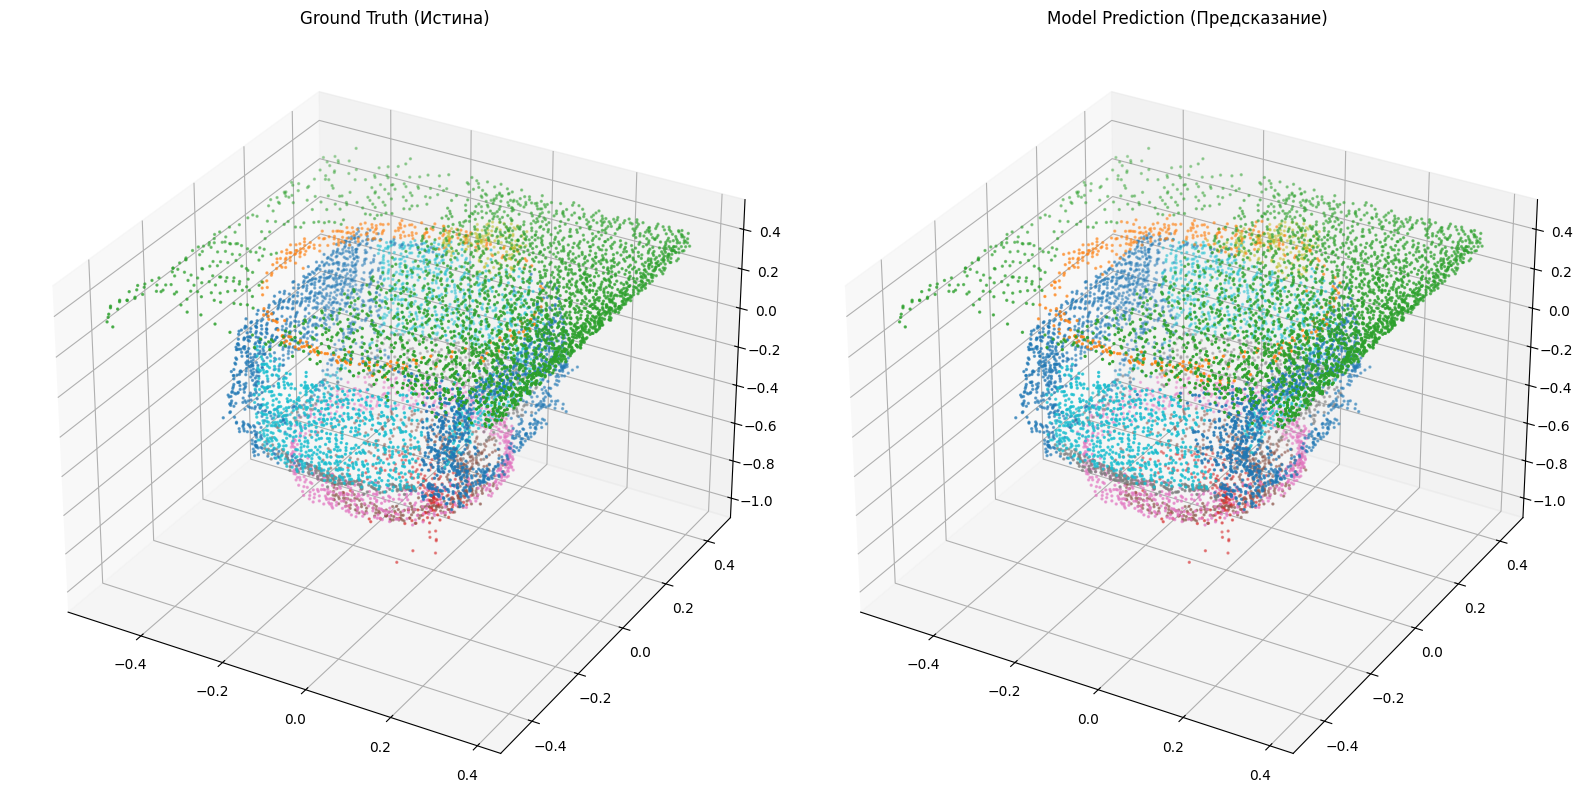

In [28]:
def visualize_result(xyz, true_labels, pred_labels, idx=0):
    fig = plt.figure(figsize=(16, 8))

    # Истинные метки
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], c=true_labels, cmap='tab10', s=2)
    ax1.set_title("Ground Truth (Истина)")

    # Предсказание
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], c=pred_labels, cmap='tab10', s=2)
    ax2.set_title("Model Prediction (Предсказание)")

    plt.tight_layout()
    plt.show()

# Берем один объект из теста
test_sample_xyz, test_sample_labels = test_ds[random.randint(0, len(test_ds)-1)]
model.eval()
with torch.no_grad():
    sample_pred = model(test_sample_xyz.unsqueeze(0).to(DEVICE))
    sample_pred = sample_pred.argmax(dim=-1).cpu().numpy()[0]

visualize_result(test_sample_xyz.numpy(), test_sample_labels.numpy(), sample_pred)

#PointNet

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PointNetSemSeg(nn.Module):
    def __init__(self, num_classes=9):
        super(PointNetSemSeg, self).__init__()

        self.conv1 = nn.Conv1d(3, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, 1024, 1)
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)


        self.conv4 = nn.Conv1d(1088, 512, 1)
        self.conv5 = nn.Conv1d(512, 256, 1)
        self.conv6 = nn.Conv1d(256, 128, 1)
        self.conv7 = nn.Conv1d(128, num_classes, 1)
        self.bn4 = nn.BatchNorm1d(512)
        self.bn5 = nn.BatchNorm1d(256)
        self.bn6 = nn.BatchNorm1d(128)

    def forward(self, x):
        B, N, _ = x.shape
        x = x.transpose(1, 2) # (B, 3, N)

        # 1. Извлекаем локальные признаки
        x = F.relu(self.bn1(self.conv1(x)))
        point_feat = x # Сохраняем локальные признаки (B, 64, N)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))

        # 2. Извлекаем глобальный признак (максимум по всему облаку)
        global_feat = torch.max(x, 2, keepdim=True)[0] # (B, 1024, 1)
        global_feat_expand = global_feat.repeat(1, 1, N) # (B, 1024, N)

        # 3. Конкатенация (Глобальный контекст + Локальная точка)
        x = torch.cat([point_feat, global_feat_expand], 1) # (B, 1088, N)

        # 4. Классификация каждой точки
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.conv7(x)

        return x.transpose(1, 2) # (B, N, num_classes)

In [18]:

pn_model = PointNetSemSeg(num_classes=NUM_CLASSES).to(DEVICE)

optimizer = torch.optim.Adam(pn_model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor) # Веса классов важны!


pn_history = {
    'train_loss': [],
    'val_loss': [],
    'val_oa': [],
    'val_miou': []
}

best_pn_miou = 0
EPOCHS = 50

In [19]:
@torch.no_grad()
def compute_metrics(all_preds, all_labels, num_classes=9):
    """Расчет OA, mIoU и IoU по классам."""

    oa = (all_preds == all_labels).sum() / len(all_labels)


    ious = []
    for c in range(num_classes):
        pred_c = (all_preds == c)
        true_c = (all_labels == c)
        intersection = (pred_c & true_c).sum()
        union = (pred_c | true_c).sum()
        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(intersection / union)

    miou = np.nanmean(ious)
    return oa, miou, np.array(ious)

@torch.no_grad()
def evaluate(model, loader):
    """Полная оценка модели на заданном лоадере."""
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    count = 0

    for xyz, labels in loader:
        xyz, labels = xyz.to(DEVICE), labels.to(DEVICE)


        logits = model(xyz)

        loss = F.cross_entropy(logits.reshape(-1, NUM_CLASSES),
                               labels.reshape(-1),
                               weight=class_weights_tensor)

        total_loss += loss.item() * xyz.size(0)
        count += xyz.size(0)

        preds = logits.argmax(dim=-1).cpu().numpy().flatten()
        lbls  = labels.cpu().numpy().flatten()
        all_preds.append(preds)
        all_labels.append(lbls)

    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    avg_loss = total_loss / count
    oa, miou, ious = compute_metrics(all_preds, all_labels, NUM_CLASSES)

    return avg_loss, oa, miou, ious, all_preds, all_labels

In [23]:
# Переопределяем загрузчики с num_workers=0, чтобы не было ошибок в Colab

NUM_CLASSES = 9
BATCH_SIZE = 16
EPOCHS = 50
LR = 0.001


test_ds = PointCloudDataset(test_files, num_points=8192, augment=False)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=2)
train_ds = PointCloudDataset(train_files, num_points=8192, augment=True)
val_ds = PointCloudDataset(val_files, num_points=8192, augment=False)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=True)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=True)

print("Загрузчики обновлены (num_workers=0). Теперь ошибки быть не должно.")

Загрузчики обновлены (num_workers=0). Теперь ошибки быть не должно.


In [24]:
from tqdm import tqdm

print("=== Запуск обучения PointNet (Baseline) ===")

for epoch in range(1, EPOCHS + 1):

    pn_model.train()
    running_train_loss = 0.0

    for xyz, labels in train_loader:
        xyz, labels = xyz.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        preds = pn_model(xyz)
        loss = criterion(preds.reshape(-1, NUM_CLASSES), labels.reshape(-1))

        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)


    v_loss, v_oa, v_miou, v_ious, _, _ = evaluate(pn_model, val_loader)


    pn_history['train_loss'].append(avg_train_loss)
    pn_history['val_loss'].append(v_loss)
    pn_history['val_oa'].append(v_oa)
    pn_history['val_miou'].append(v_miou)


    print(f"Epoch [{epoch}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {v_loss:.4f} | Val mIoU: {v_miou:.4f}")


    if v_miou > best_pn_miou:
        best_pn_miou = v_miou
        torch.save(pn_model.state_dict(), 'best_pointnet_baseline.pth')
        print(f"  -> Сохранена лучшая модель (mIoU: {best_pn_miou:.4f})")

    scheduler.step()

print("\nОбучение PointNet завершено")

=== Запуск обучения PointNet (Baseline) ===
Epoch [1/50] | Train Loss: 1.5854 | Val Loss: 1.3881 | Val mIoU: 0.0865
  -> Сохранена лучшая модель (mIoU: 0.0865)
Epoch [2/50] | Train Loss: 0.9978 | Val Loss: 0.9069 | Val mIoU: 0.1920
  -> Сохранена лучшая модель (mIoU: 0.1920)
Epoch [3/50] | Train Loss: 0.7147 | Val Loss: 0.6962 | Val mIoU: 0.2626
  -> Сохранена лучшая модель (mIoU: 0.2626)
Epoch [4/50] | Train Loss: 0.6496 | Val Loss: 0.7911 | Val mIoU: 0.2457
Epoch [5/50] | Train Loss: 0.5658 | Val Loss: 0.6640 | Val mIoU: 0.3220
  -> Сохранена лучшая модель (mIoU: 0.3220)
Epoch [6/50] | Train Loss: 0.5289 | Val Loss: 1.4125 | Val mIoU: 0.1666
Epoch [7/50] | Train Loss: 0.5368 | Val Loss: 0.5888 | Val mIoU: 0.3545
  -> Сохранена лучшая модель (mIoU: 0.3545)
Epoch [8/50] | Train Loss: 0.4976 | Val Loss: 0.6138 | Val mIoU: 0.2289
Epoch [9/50] | Train Loss: 0.4364 | Val Loss: 0.4385 | Val mIoU: 0.3978
  -> Сохранена лучшая модель (mIoU: 0.3978)
Epoch [10/50] | Train Loss: 0.4431 | Val Los

In [25]:

pn_model.load_state_dict(torch.load('best_pointnet_baseline.pth'))

test_loss_pn, test_oa_pn, test_miou_pn, test_ious_pn, test_preds_pn, test_labels_pn = evaluate(pn_model, test_loader)

print("\n=== ИТОГОВЫЕ МЕТРИКИ POINTNET НА TEST SET ===")
print(f"Overall Accuracy: {test_oa_pn:.4f}")
print(f"Mean IoU:         {test_miou_pn:.4f}")


=== ИТОГОВЫЕ МЕТРИКИ POINTNET НА TEST SET ===
Overall Accuracy: 0.9038
Mean IoU:         0.6436


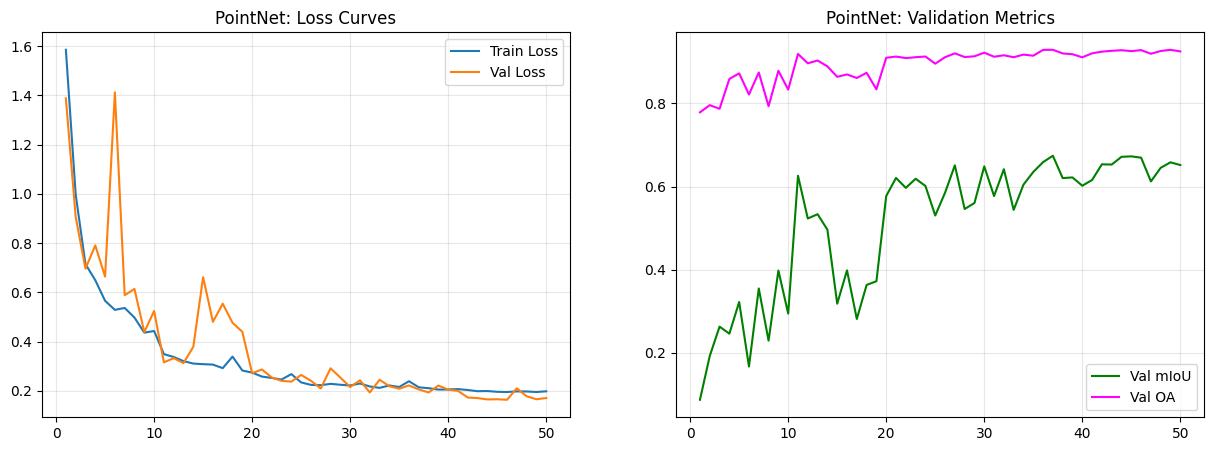

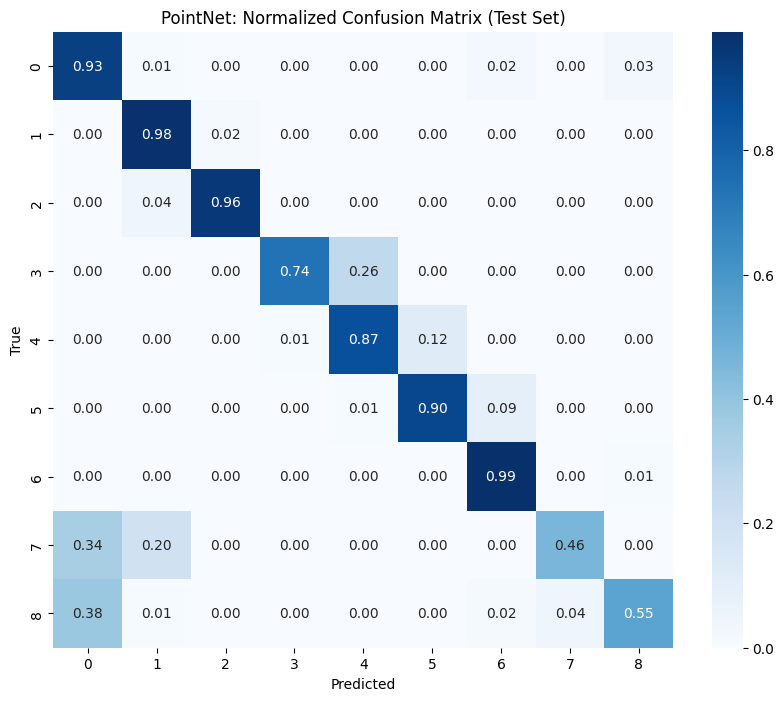

In [27]:
import seaborn as sns
from sklearn.metrics import confusion_matrix


epochs_range = range(1, len(pn_history['train_loss']) + 1)
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, pn_history['train_loss'], label='Train Loss')
plt.plot(epochs_range, pn_history['val_loss'], label='Val Loss')
plt.title('PointNet: Loss Curves'); plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, pn_history['val_miou'], label='Val mIoU', color='green')
plt.plot(epochs_range, pn_history['val_oa'], label='Val OA', color='magenta')
plt.title('PointNet: Validation Metrics'); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

cm = confusion_matrix(test_labels_pn.flatten(), test_preds_pn.flatten())
cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap='Blues')
plt.title('PointNet: Normalized Confusion Matrix (Test Set)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()

#DGCNN (Dynamic Graph CNN)


In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def get_graph_feature(x, k=20, idx=None):
    batch_size = x.size(0)
    num_points = x.size(2)
    x = x.view(batch_size, -1, num_points)
    if idx is None:
        inner = -2 * torch.matmul(x.transpose(2, 1), x)
        xx = torch.sum(x**2, dim=1, keepdim=True)
        pairwise_distance = -xx - inner - xx.transpose(2, 1)
        idx = pairwise_distance.topk(k=k, dim=-1)[1]   # (batch_size, num_points, k)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    idx_base = torch.arange(0, batch_size, device=device).view(-1, 1, 1) * num_points
    idx = idx + idx_base
    idx = idx.view(-1)

    _, num_dims, _ = x.size()
    x = x.transpose(2, 1).contiguous()
    feature = x.view(batch_size * num_points, -1)[idx, :]
    feature = feature.view(batch_size, num_points, k, num_dims)
    x = x.view(batch_size, num_points, 1, num_dims).repeat(1, 1, k, 1)

    feature = torch.cat((feature - x, x), dim=3).permute(0, 3, 1, 2).contiguous()
    return feature

class DGCNN_SemSeg(nn.Module):
    def __init__(self, k=20, num_classes=9):
        super(DGCNN_SemSeg, self).__init__()
        self.k = k

        self.bn1 = nn.BatchNorm2d(64)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm1d(64)
        self.bn4 = nn.BatchNorm1d(1024)

        self.conv1 = nn.Sequential(nn.Conv2d(6, 64, kernel_size=1, bias=False), self.bn1, nn.LeakyReLU(0.2))
        self.conv2 = nn.Sequential(nn.Conv2d(64*2, 64, kernel_size=1, bias=False), self.bn2, nn.LeakyReLU(0.2))
        self.conv3 = nn.Sequential(nn.Conv1d(64, 64, kernel_size=1, bias=False), self.bn3, nn.LeakyReLU(0.2))
        self.conv4 = nn.Sequential(nn.Conv1d(128, 1024, kernel_size=1, bias=False), self.bn4, nn.LeakyReLU(0.2))

        self.conv5 = nn.Sequential(nn.Conv1d(1024+128, 512, kernel_size=1, bias=False), nn.BatchNorm1d(512), nn.LeakyReLU(0.2))
        self.conv6 = nn.Sequential(nn.Conv1d(512, 256, kernel_size=1, bias=False), nn.BatchNorm1d(256), nn.LeakyReLU(0.2))
        self.conv7 = nn.Conv1d(256, num_classes, kernel_size=1)

    def forward(self, x):
        B, N, _ = x.shape
        x = x.transpose(1, 2) # (B, 3, N)

        x = get_graph_feature(x, k=self.k)      # (B, 3, N) -> (B, 6, N, k)
        x = self.conv1(x)                       # (B, 6, N, k) -> (B, 64, N, k)
        x1 = x.max(dim=-1, keepdim=False)[0]    # (B, 64, N)

        x = get_graph_feature(x1, k=self.k)     # (B, 64, N) -> (B, 128, N, k)
        x = self.conv2(x)                       # (B, 128, N, k) -> (B, 64, N, k)
        x2 = x.max(dim=-1, keepdim=False)[0]    # (B, 64, N)

        x3 = self.conv3(x2)                     # (B, 64, N)

        x = torch.cat((x1, x2, x3), dim=1)      # (B, 192, N)
        x = self.conv4(torch.cat((x1, x2), dim=1)) # (B, 1024, N)

        global_feat = x.max(dim=-1, keepdim=True)[0] # (B, 1024, 1)
        global_feat = global_feat.repeat(1, 1, N)    # (B, 1024, N)

        x = torch.cat((x, global_feat, x1, x2), dim=1) # (B, 1024+128+1024, N) - упростим для памяти
        x = torch.cat((global_feat, x1, x2), dim=1)    # (B, 1024+128, N)

        x = self.conv5(x)
        x = self.conv6(x)
        x = self.conv7(x)
        return x.transpose(1, 2)

In [33]:

BATCH_SIZE = 4


train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=True)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=True)

print(f"BATCH_SIZE изменен на {BATCH_SIZE}. Загрузчики обновлены.")

BATCH_SIZE изменен на 4. Загрузчики обновлены.


In [34]:

dg_model = DGCNN_SemSeg(num_classes=NUM_CLASSES).to(DEVICE)
optimizer = torch.optim.Adam(dg_model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)


dg_history = {
    'train_loss': [],
    'val_loss': [],
    'val_oa': [],
    'val_miou': []
}

best_dg_miou = 0
EPOCHS = 50

print("=== Запуск обучения DGCNN (Graph CNN) ===")

for epoch in range(1, EPOCHS + 1):

    dg_model.train()
    running_loss = 0.0
    for xyz, labels in train_loader:
        xyz, labels = xyz.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        preds = dg_model(xyz)
        loss = criterion(preds.reshape(-1, NUM_CLASSES), labels.reshape(-1))
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)


    v_loss, v_oa, v_miou, v_ious, _, _ = evaluate(dg_model, val_loader)


    dg_history['train_loss'].append(avg_train_loss)
    dg_history['val_loss'].append(v_loss)
    dg_history['val_oa'].append(v_oa)
    dg_history['val_miou'].append(v_miou)

    print(f"Epoch [{epoch}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val mIoU: {v_miou:.4f} | Val OA: {v_oa:.4f}")


    if v_miou > best_dg_miou:
        best_dg_miou = v_miou
        torch.save(dg_model.state_dict(), 'best_dgcnn_model.pth')
        print(f"  -> Сохранена лучшая модель DGCNN (mIoU: {best_dg_miou:.4f})")

    scheduler.step()

print("\nОбучение DGCNN завершено!")

=== Запуск обучения DGCNN (Graph CNN) ===
Epoch [1/50] | Train Loss: 1.1895 | Val mIoU: 0.4070 | Val OA: 0.8877
  -> Сохранена лучшая модель DGCNN (mIoU: 0.4070)
Epoch [2/50] | Train Loss: 0.7302 | Val mIoU: 0.5128 | Val OA: 0.8937
  -> Сохранена лучшая модель DGCNN (mIoU: 0.5128)
Epoch [3/50] | Train Loss: 0.3978 | Val mIoU: 0.5335 | Val OA: 0.9190
  -> Сохранена лучшая модель DGCNN (mIoU: 0.5335)
Epoch [4/50] | Train Loss: 0.3177 | Val mIoU: 0.6586 | Val OA: 0.9251
  -> Сохранена лучшая модель DGCNN (mIoU: 0.6586)
Epoch [5/50] | Train Loss: 0.2746 | Val mIoU: 0.3890 | Val OA: 0.8614
Epoch [6/50] | Train Loss: 0.2446 | Val mIoU: 0.3230 | Val OA: 0.8783
Epoch [7/50] | Train Loss: 0.2074 | Val mIoU: 0.7032 | Val OA: 0.9335
  -> Сохранена лучшая модель DGCNN (mIoU: 0.7032)
Epoch [8/50] | Train Loss: 0.1885 | Val mIoU: 0.4765 | Val OA: 0.9032
Epoch [9/50] | Train Loss: 0.2261 | Val mIoU: 0.5924 | Val OA: 0.9243
Epoch [10/50] | Train Loss: 0.1754 | Val mIoU: 0.5822 | Val OA: 0.9137
Epoch [


=== ИТОГОВЫЕ МЕТРИКИ DGCNN НА TEST SET ===
Overall Accuracy: 0.9563
Mean IoU:         0.8174


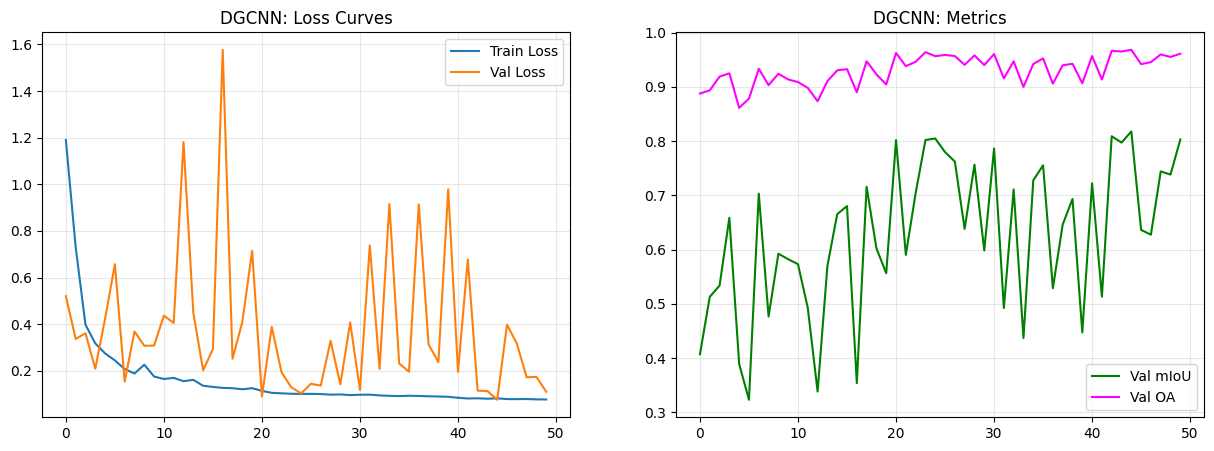

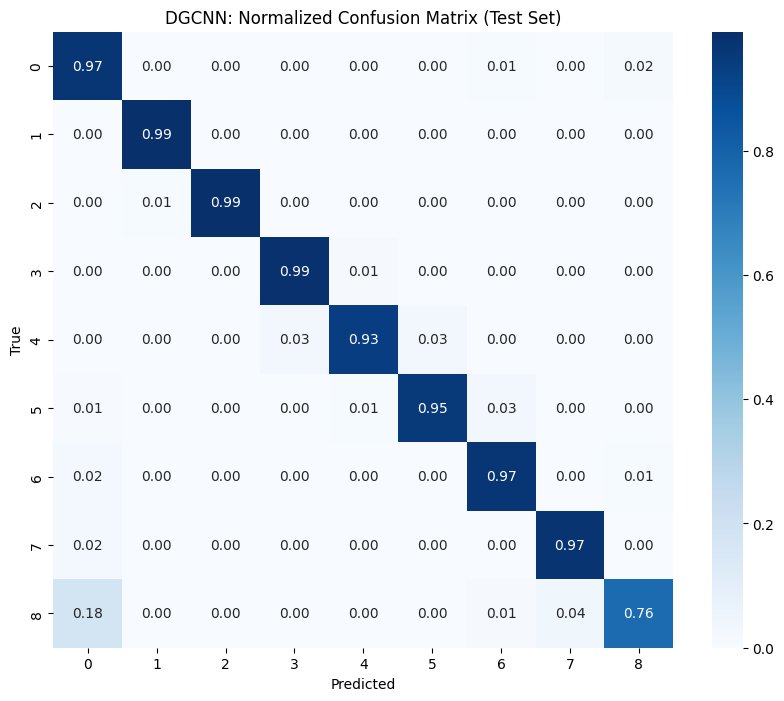

In [37]:

dg_model.load_state_dict(torch.load('best_dgcnn_model.pth'))
test_loss_dg, test_oa_dg, test_miou_dg, test_ious_dg, test_preds_dg, test_labels_dg = evaluate(dg_model, test_loader)

print("\n=== ИТОГОВЫЕ МЕТРИКИ DGCNN НА TEST SET ===")
print(f"Overall Accuracy: {test_oa_dg:.4f}")
print(f"Mean IoU:         {test_miou_dg:.4f}")


plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(dg_history['train_loss'], label='Train Loss')
plt.plot(dg_history['val_loss'], label='Val Loss')
plt.title('DGCNN: Loss Curves'); plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(dg_history['val_miou'], label='Val mIoU', color='green')
plt.plot(dg_history['val_oa'], label='Val OA', color='magenta')
plt.title('DGCNN: Metrics'); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()


cm = confusion_matrix(test_labels_dg.flatten(), test_preds_dg.flatten())
cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap='Blues')
plt.title('DGCNN: Normalized Confusion Matrix (Test Set)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()


=== ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ ===
             Модель  Overall Accuracy  Mean IoU (mIoU)
PointNet (Baseline)            0.9038           0.6436
  PointNet++ (SOTA)            0.9349           0.8459
      DGCNN (Graph)            0.9563           0.8174


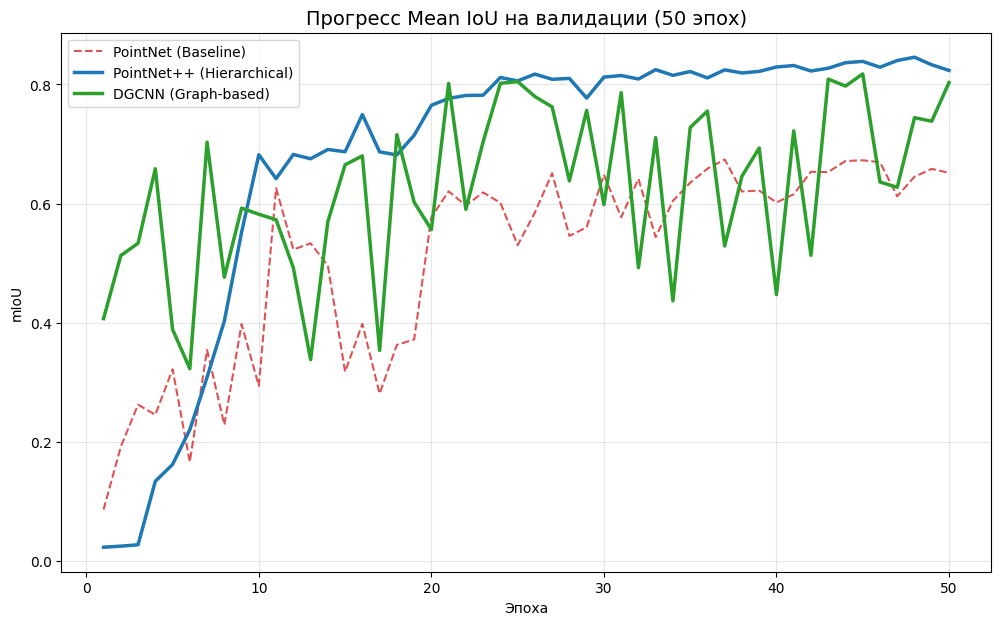

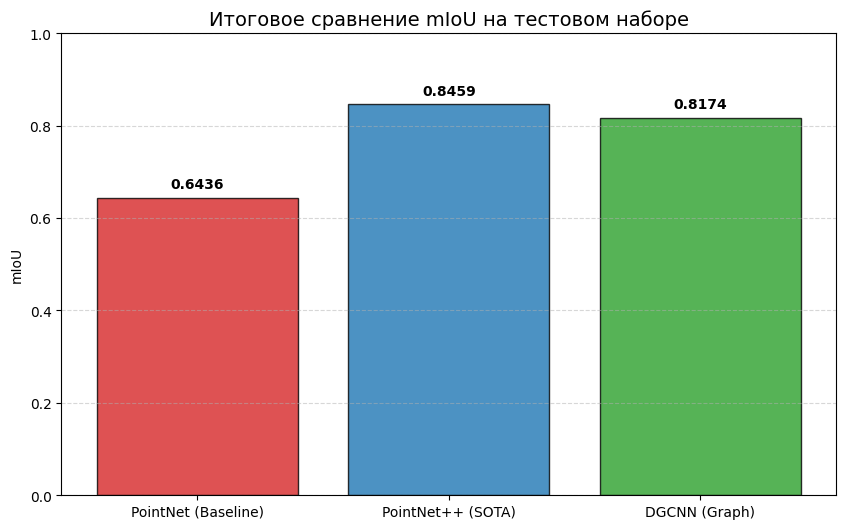


Все графики построены. Файлы 'comparison_progress.png' и 'final_miou_comparison.png' сохранены.


In [47]:
import re
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

log_pp = """
Epoch 1: Loss 1.7987, Val mIoU: 0.0234, OA: 0.2107
Epoch 2: Loss 1.0715, Val mIoU: 0.0252, OA: 0.1951
Epoch 3: Loss 0.7308, Val mIoU: 0.0275, OA: 0.1735
Epoch 4: Loss 0.5791, Val mIoU: 0.1341, OA: 0.5186
Epoch 5: Loss 0.5014, Val mIoU: 0.1623, OA: 0.5591
Epoch 6: Loss 0.4444, Val mIoU: 0.2207, OA: 0.5368
Epoch 7: Loss 0.4118, Val mIoU: 0.3087, OA: 0.6030
Epoch 8: Loss 0.3810, Val mIoU: 0.4028, OA: 0.6660
Epoch 9: Loss 0.3745, Val mIoU: 0.5521, OA: 0.7625
Epoch 10: Loss 0.3630, Val mIoU: 0.6820, OA: 0.8218
Epoch 11: Loss 0.3441, Val mIoU: 0.6419, OA: 0.8130
Epoch 12: Loss 0.3182, Val mIoU: 0.6825, OA: 0.8261
Epoch 13: Loss 0.3155, Val mIoU: 0.6753, OA: 0.8363
Epoch 14: Loss 0.3026, Val mIoU: 0.6909, OA: 0.8353
Epoch 15: Loss 0.2844, Val mIoU: 0.6871, OA: 0.8118
Epoch 16: Loss 0.2801, Val mIoU: 0.7495, OA: 0.8670
Epoch 17: Loss 0.2725, Val mIoU: 0.6868, OA: 0.8444
Epoch 18: Loss 0.2635, Val mIoU: 0.6818, OA: 0.8542
Epoch 19: Loss 0.2630, Val mIoU: 0.7147, OA: 0.8544
Epoch 20: Loss 0.2515, Val mIoU: 0.7650, OA: 0.8950
Epoch 21: Loss 0.2339, Val mIoU: 0.7766, OA: 0.8975
Epoch 22: Loss 0.2155, Val mIoU: 0.7815, OA: 0.8977
Epoch 23: Loss 0.2199, Val mIoU: 0.7820, OA: 0.9039
Epoch 24: Loss 0.2133, Val mIoU: 0.8117, OA: 0.9189
Epoch 25: Loss 0.2102, Val mIoU: 0.8059, OA: 0.9162
Epoch 26: Loss 0.2101, Val mIoU: 0.8174, OA: 0.9182
Epoch 27: Loss 0.2045, Val mIoU: 0.8087, OA: 0.9172
Epoch 28: Loss 0.2130, Val mIoU: 0.8101, OA: 0.9180
Epoch 29: Loss 0.2055, Val mIoU: 0.7771, OA: 0.9036
Epoch 30: Loss 0.2033, Val mIoU: 0.8123, OA: 0.9212
Epoch 31: Loss 0.1978, Val mIoU: 0.8150, OA: 0.9177
Epoch 32: Loss 0.1986, Val mIoU: 0.8091, OA: 0.9163
Epoch 33: Loss 0.1935, Val mIoU: 0.8248, OA: 0.9238
Epoch 34: Loss 0.1927, Val mIoU: 0.8153, OA: 0.9194
Epoch 35: Loss 0.1940, Val mIoU: 0.8217, OA: 0.9228
Epoch 36: Loss 0.1947, Val mIoU: 0.8110, OA: 0.9119
Epoch 37: Loss 0.1919, Val mIoU: 0.8245, OA: 0.9246
Epoch 38: Loss 0.1898, Val mIoU: 0.8193, OA: 0.9189
Epoch 39: Loss 0.1903, Val mIoU: 0.8219, OA: 0.9246
Epoch 40: Loss 0.1897, Val mIoU: 0.8293, OA: 0.9280
Epoch 41: Loss 0.1857, Val mIoU: 0.8318, OA: 0.9301
Epoch 42: Loss 0.1811, Val mIoU: 0.8226, OA: 0.9259
Epoch 43: Loss 0.1805, Val mIoU: 0.8272, OA: 0.9284
Epoch 44: Loss 0.1744, Val mIoU: 0.8365, OA: 0.9302
Epoch 45: Loss 0.1748, Val mIoU: 0.8387, OA: 0.9313
Epoch 46: Loss 0.1777, Val mIoU: 0.8289, OA: 0.9293
Epoch 47: Loss 0.1769, Val mIoU: 0.8402, OA: 0.9331
Epoch 48: Loss 0.1730, Val mIoU: 0.8457, OA: 0.9341
Epoch 49: Loss 0.1712, Val mIoU: 0.8330, OA: 0.9307
Epoch 50: Loss 0.1755, Val mIoU: 0.8235, OA: 0.9304
"""

log_pn = """
Epoch [1/50] | Train Loss: 1.5854 | Val Loss: 1.3881 | Val mIoU: 0.0865
Epoch [2/50] | Train Loss: 0.9978 | Val Loss: 0.9069 | Val mIoU: 0.1920
Epoch [3/50] | Train Loss: 0.7147 | Val Loss: 0.6962 | Val mIoU: 0.2626
Epoch [4/50] | Train Loss: 0.6496 | Val Loss: 0.7911 | Val mIoU: 0.2457
Epoch [5/50] | Train Loss: 0.5658 | Val Loss: 0.6640 | Val mIoU: 0.3220
Epoch [6/50] | Train Loss: 0.5289 | Val Loss: 1.4125 | Val mIoU: 0.1666
Epoch [7/50] | Train Loss: 0.5368 | Val Loss: 0.5888 | Val mIoU: 0.3545
Epoch [8/50] | Train Loss: 0.4976 | Val Loss: 0.6138 | Val mIoU: 0.2289
Epoch [9/50] | Train Loss: 0.4364 | Val Loss: 0.4385 | Val mIoU: 0.3978
Epoch [10/50] | Train Loss: 0.4431 | Val Loss: 0.5244 | Val mIoU: 0.2942
Epoch [11/50] | Train Loss: 0.3492 | Val Loss: 0.3158 | Val mIoU: 0.6259
Epoch [12/50] | Train Loss: 0.3375 | Val Loss: 0.3329 | Val mIoU: 0.5230
Epoch [13/50] | Train Loss: 0.3207 | Val Loss: 0.3127 | Val mIoU: 0.5334
Epoch [14/50] | Train Loss: 0.3108 | Val Loss: 0.3789 | Val mIoU: 0.4961
Epoch [15/50] | Train Loss: 0.3084 | Val Loss: 0.6617 | Val mIoU: 0.3179
Epoch [16/50] | Train Loss: 0.3066 | Val Loss: 0.4804 | Val mIoU: 0.3982
Epoch [17/50] | Train Loss: 0.2922 | Val Loss: 0.5541 | Val mIoU: 0.2811
Epoch [18/50] | Train Loss: 0.3390 | Val Loss: 0.4766 | Val mIoU: 0.3630
Epoch [19/50] | Train Loss: 0.2827 | Val Loss: 0.4397 | Val mIoU: 0.3720
Epoch [20/50] | Train Loss: 0.2741 | Val Loss: 0.2716 | Val mIoU: 0.5773
Epoch [21/50] | Train Loss: 0.2580 | Val Loss: 0.2868 | Val mIoU: 0.6207
Epoch [22/50] | Train Loss: 0.2524 | Val Loss: 0.2544 | Val mIoU: 0.5968
Epoch [23/50] | Train Loss: 0.2460 | Val Loss: 0.2406 | Val mIoU: 0.6188
Epoch [24/50] | Train Loss: 0.2681 | Val Loss: 0.2375 | Val mIoU: 0.6013
Epoch [25/50] | Train Loss: 0.2343 | Val Loss: 0.2646 | Val mIoU: 0.5303
Epoch [26/50] | Train Loss: 0.2242 | Val Loss: 0.2410 | Val mIoU: 0.5851
Epoch [27/50] | Train Loss: 0.2231 | Val Loss: 0.2096 | Val mIoU: 0.6511
Epoch [28/50] | Train Loss: 0.2285 | Val Loss: 0.2916 | Val mIoU: 0.5459
Epoch [29/50] | Train Loss: 0.2248 | Val Loss: 0.2538 | Val mIoU: 0.5604
Epoch [30/50] | Train Loss: 0.2219 | Val Loss: 0.2155 | Val mIoU: 0.6485
Epoch [31/50] | Train Loss: 0.2298 | Val Loss: 0.2428 | Val mIoU: 0.5771
Epoch [32/50] | Train Loss: 0.2178 | Val Loss: 0.1935 | Val mIoU: 0.6417
Epoch [33/50] | Train Loss: 0.2121 | Val Loss: 0.2450 | Val mIoU: 0.5438
Epoch [34/50] | Train Loss: 0.2219 | Val Loss: 0.2187 | Val mIoU: 0.6046
Epoch [35/50] | Train Loss: 0.2157 | Val Loss: 0.2087 | Val mIoU: 0.6351
Epoch [36/50] | Train Loss: 0.2391 | Val Loss: 0.2220 | Val mIoU: 0.6587
Epoch [37/50] | Train Loss: 0.2144 | Val Loss: 0.2058 | Val mIoU: 0.6741
Epoch [38/50] | Train Loss: 0.2108 | Val Loss: 0.1934 | Val mIoU: 0.6204
Epoch [39/50] | Train Loss: 0.2051 | Val Loss: 0.2216 | Val mIoU: 0.6219
Epoch [40/50] | Train Loss: 0.2056 | Val Loss: 0.2047 | Val mIoU: 0.6020
Epoch [41/50] | Train Loss: 0.2071 | Val Loss: 0.2000 | Val mIoU: 0.6158
Epoch [42/50] | Train Loss: 0.2034 | Val Loss: 0.1729 | Val mIoU: 0.6535
Epoch [43/50] | Train Loss: 0.1986 | Val Loss: 0.1705 | Val mIoU: 0.6529
Epoch [44/50] | Train Loss: 0.1992 | Val Loss: 0.1652 | Val mIoU: 0.6716
Epoch [45/50] | Train Loss: 0.1961 | Val Loss: 0.1657 | Val mIoU: 0.6727
Epoch [46/50] | Train Loss: 0.1953 | Val Loss: 0.1637 | Val mIoU: 0.6695
Epoch [47/50] | Train Loss: 0.1977 | Val Loss: 0.2106 | Val mIoU: 0.6124
Epoch [48/50] | Train Loss: 0.1975 | Val Loss: 0.1779 | Val mIoU: 0.6452
Epoch [49/50] | Train Loss: 0.1954 | Val Loss: 0.1659 | Val mIoU: 0.6583
Epoch [50/50] | Train Loss: 0.1981 | Val Loss: 0.1708 | Val mIoU: 0.6517
"""

log_dg = """
Epoch [1/50] | Train Loss: 1.1895 | Val mIoU: 0.4070 | Val OA: 0.8877
Epoch [2/50] | Train Loss: 0.7302 | Val mIoU: 0.5128 | Val OA: 0.8937
Epoch [3/50] | Train Loss: 0.3978 | Val mIoU: 0.5335 | Val OA: 0.9190
Epoch [4/50] | Train Loss: 0.3177 | Val mIoU: 0.6586 | Val OA: 0.9251
Epoch [5/50] | Train Loss: 0.2746 | Val mIoU: 0.3890 | Val OA: 0.8614
Epoch [6/50] | Train Loss: 0.2446 | Val mIoU: 0.3230 | Val OA: 0.8783
Epoch [7/50] | Train Loss: 0.2074 | Val mIoU: 0.7032 | Val OA: 0.9335
Epoch [8/50] | Train Loss: 0.1885 | Val mIoU: 0.4765 | Val OA: 0.9032
Epoch [9/50] | Train Loss: 0.2261 | Val mIoU: 0.5924 | Val OA: 0.9243
Epoch [10/50] | Train Loss: 0.1754 | Val mIoU: 0.5822 | Val OA: 0.9137
Epoch [11/50] | Train Loss: 0.1648 | Val mIoU: 0.5730 | Val OA: 0.9089
Epoch [12/50] | Train Loss: 0.1697 | Val mIoU: 0.4923 | Val OA: 0.8982
Epoch [13/50] | Train Loss: 0.1555 | Val mIoU: 0.3381 | Val OA: 0.8735
Epoch [14/50] | Train Loss: 0.1612 | Val mIoU: 0.5697 | Val OA: 0.9105
Epoch [15/50] | Train Loss: 0.1358 | Val mIoU: 0.6652 | Val OA: 0.9306
Epoch [16/50] | Train Loss: 0.1309 | Val mIoU: 0.6802 | Val OA: 0.9327
Epoch [17/50] | Train Loss: 0.1267 | Val mIoU: 0.3537 | Val OA: 0.8901
Epoch [18/50] | Train Loss: 0.1253 | Val mIoU: 0.7157 | Val OA: 0.9473
Epoch [19/50] | Train Loss: 0.1207 | Val mIoU: 0.6024 | Val OA: 0.9232
Epoch [20/50] | Train Loss: 0.1254 | Val mIoU: 0.5564 | Val OA: 0.9044
Epoch [21/50] | Train Loss: 0.1139 | Val mIoU: 0.8018 | Val OA: 0.9626
Epoch [22/50] | Train Loss: 0.1054 | Val mIoU: 0.5903 | Val OA: 0.9383
Epoch [23/50] | Train Loss: 0.1034 | Val mIoU: 0.7040 | Val OA: 0.9462
Epoch [24/50] | Train Loss: 0.1014 | Val mIoU: 0.8020 | Val OA: 0.9641
Epoch [25/50] | Train Loss: 0.1009 | Val mIoU: 0.8048 | Val OA: 0.9567
Epoch [26/50] | Train Loss: 0.1010 | Val mIoU: 0.7797 | Val OA: 0.9589
Epoch [27/50] | Train Loss: 0.1002 | Val mIoU: 0.7623 | Val OA: 0.9569
Epoch [28/50] | Train Loss: 0.0977 | Val mIoU: 0.6382 | Val OA: 0.9406
Epoch [29/50] | Train Loss: 0.0986 | Val mIoU: 0.7566 | Val OA: 0.9581
Epoch [30/50] | Train Loss: 0.0959 | Val mIoU: 0.5984 | Val OA: 0.9402
Epoch [31/50] | Train Loss: 0.0972 | Val mIoU: 0.7863 | Val OA: 0.9605
Epoch [32/50] | Train Loss: 0.0977 | Val mIoU: 0.4923 | Val OA: 0.9158
Epoch [33/50] | Train Loss: 0.0944 | Val mIoU: 0.7109 | Val OA: 0.9471
Epoch [34/50] | Train Loss: 0.0928 | Val mIoU: 0.4368 | Val OA: 0.9000
Epoch [35/50] | Train Loss: 0.0915 | Val mIoU: 0.7278 | Val OA: 0.9422
Epoch [36/50] | Train Loss: 0.0930 | Val mIoU: 0.7554 | Val OA: 0.9525
Epoch [37/50] | Train Loss: 0.0921 | Val mIoU: 0.5288 | Val OA: 0.9060
Epoch [38/50] | Train Loss: 0.0905 | Val mIoU: 0.6461 | Val OA: 0.9398
Epoch [39/50] | Train Loss: 0.0898 | Val mIoU: 0.6933 | Val OA: 0.9426
Epoch [40/50] | Train Loss: 0.0886 | Val mIoU: 0.4472 | Val OA: 0.9067
Epoch [41/50] | Train Loss: 0.0843 | Val mIoU: 0.7222 | Val OA: 0.9569
Epoch [42/50] | Train Loss: 0.0812 | Val mIoU: 0.5131 | Val OA: 0.9136
Epoch [43/50] | Train Loss: 0.0821 | Val mIoU: 0.8090 | Val OA: 0.9665
Epoch [44/50] | Train Loss: 0.0803 | Val mIoU: 0.7973 | Val OA: 0.9652
Epoch [45/50] | Train Loss: 0.0819 | Val mIoU: 0.8177 | Val OA: 0.9685
Epoch [46/50] | Train Loss: 0.0787 | Val mIoU: 0.6362 | Val OA: 0.9419
Epoch [47/50] | Train Loss: 0.0785 | Val mIoU: 0.6274 | Val OA: 0.9457
Epoch [48/50] | Train Loss: 0.0789 | Val mIoU: 0.7442 | Val OA: 0.9599
Epoch [49/50] | Train Loss: 0.0774 | Val mIoU: 0.7383 | Val OA: 0.9552
Epoch [50/50] | Train Loss: 0.0770 | Val mIoU: 0.8031 | Val OA: 0.9612
"""

# Функция парсинга
def parse(text):
    return [float(x) for x in re.findall(r"mIoU: ([\d\.]+)", text)]

# Парсим историю
history_pp = parse(log_pp)
history_pn = parse(log_pn)
history_dg = parse(log_dg)


final_stats = {
    "Модель": ["PointNet (Baseline)", "PointNet++ (SOTA)", "DGCNN (Graph)"],
    "Overall Accuracy": [0.9038, 0.9349, 0.9563],
    "Mean IoU (mIoU)": [0.6436, 0.8459, 0.8174],
}


df_final = pd.DataFrame(final_stats)
print("\n=== ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ ===")
print("="*60)
print(df_final.to_string(index=False))
print("="*60)


plt.figure(figsize=(12, 7))
plt.plot(range(1, 51), history_pn, label='PointNet (Baseline)', color='tab:red', linestyle='--', alpha=0.8)
plt.plot(range(1, 51), history_pp, label='PointNet++ (Hierarchical)', color='tab:blue', linewidth=2.5)
plt.plot(range(1, 51), history_dg, label='DGCNN (Graph-based)', color='tab:green', linewidth=2.5)

plt.title('Прогресс Mean IoU на валидации (50 эпох)', fontsize=14)
plt.xlabel('Эпоха')
plt.ylabel('mIoU')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('comparison_progress.png', dpi=150)
plt.show()


plt.figure(figsize=(10, 6))
colors = ['tab:red', 'tab:blue', 'tab:green']
bars = plt.bar(final_stats["Модель"], final_stats["Mean IoU (mIoU)"], color=colors, alpha=0.8, edgecolor='black')

plt.title('Итоговое сравнение mIoU на тестовом наборе', fontsize=14)
plt.ylabel('mIoU')
plt.ylim(0, 1.0)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('final_miou_comparison.png', dpi=150)
plt.show()

print("\nВсе графики построены. Файлы 'comparison_progress.png' и 'final_miou_comparison.png' сохранены.")